In [1]:
# 1. Importar bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import gdown
import numpy as np
import matplotlib.lines as mlines
import seaborn as sns

In [2]:
#leitura do banco sem sábados e domingos
df = pd.read_csv("dados-seg.csv")
df.head(6)

,date,tipo_refeicao,restaurante_utilizado,categoria_padrao,categoria_vegano,dia_semana,mes,almoco,periodo_semestre,quantidade,feriado_dummy
0,2024-02-28,Almoço,RU,bovino,leguminosas,qua,fev,1,inicio,4112.0,0
1,2024-02-28,Almoço,RA,bovino,leguminosas,qua,fev,1,inicio,1155.0,0
2,2024-02-28,Almoço,RS,bovino,leguminosas,qua,fev,1,inicio,1384.0,0
3,2024-02-28,Jantar,RU,bovino_suino,leguminosas,qua,fev,0,inicio,2200.0,0
4,2024-02-28,Jantar,RA,bovino_suino,leguminosas,qua,fev,0,inicio,559.0,0
5,2024-02-28,Jantar,RS,bovino_suino,leguminosas,qua,fev,0,inicio,386.0,0


In [3]:
#verificar NA
df.isna().any().any()

np.True_

In [4]:
#retirada de NA do banco caso tenha
df = df.dropna()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1926 entries, 0 to 2051
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1926 non-null   object 
 1   tipo_refeicao          1926 non-null   object 
 2   restaurante_utilizado  1926 non-null   object 
 3   categoria_padrao       1926 non-null   object 
 4   categoria_vegano       1926 non-null   object 
 5   dia_semana             1926 non-null   object 
 6   mes                    1926 non-null   object 
 7   almoco                 1926 non-null   int64  
 8   periodo_semestre       1926 non-null   object 
 9   quantidade             1926 non-null   float64
 10  feriado_dummy          1926 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 180.6+ KB


Entrada são os parâmetros (features) e target é o que queremos prever


In [6]:
# 3. Pré-processamento
#
features = [
    'tipo_refeicao', 'restaurante_utilizado', 'categoria_padrao',
    'categoria_vegano', 'dia_semana', 'mes',
    'periodo_semestre', 'feriado_dummy'
]
target = 'quantidade'

# Converter variáveis categóricas em numéricas (One-Hot Encoding)
df_encoded = pd.get_dummies(df[features], drop_first=False) #transforma cada variável categórica em uma coluna de contendo true or false
# Separar X e y
X = df_encoded #tabela com os parâmetros
y = df[target] #tabela com o alvo

In [7]:
#fiz isso só para ver com quantas colunas ficamos em X
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1926 entries, 0 to 2051
Data columns (total 41 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   feriado_dummy                              1926 non-null   int64
 1   tipo_refeicao_Almoço                       1926 non-null   bool 
 2   tipo_refeicao_Jantar                       1926 non-null   bool 
 3   restaurante_utilizado_RA                   1926 non-null   bool 
 4   restaurante_utilizado_RS                   1926 non-null   bool 
 5   restaurante_utilizado_RU                   1926 non-null   bool 
 6   categoria_padrao_Outros                    1926 non-null   bool 
 7   categoria_padrao_bovino                    1926 non-null   bool 
 8   categoria_padrao_bovino_suino              1926 non-null   bool 
 9   categoria_padrao_feijoada                  1926 non-null   bool 
 10  categoria_padrao_frango                    1926 non-n

In [8]:
# 4. Separar dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #test_size define o taxa de aprendizado,
                                                                                            #random_state garante uma semente para a aleatoriedade

# 5. Criar o modelo
modelo = DecisionTreeRegressor(max_depth=20, random_state=42) #max_depth define a profundidade máxima da árvore

In [9]:
# 6. Treinar
modelo.fit(X_train, y_train)

# 7. Fazer previsões
y_pred = modelo.predict(X_test)

In [10]:
#estatisticas de treino
y_pred_train = modelo.predict(X_train)
r2=r2_score(y_train, y_pred_train)
print("Erro absoluto médio (MAE):", mean_absolute_error(y_train, y_pred_train))
print("R² (coeficiente de determinação):", r2_score(y_train, y_pred_train))
print("Raiz do erro quadrático médio (RMSE):", np.sqrt(mean_squared_error(y_train, y_pred_train)))

Erro absoluto médio (MAE): 46.1628231292517
R² (coeficiente de determinação): 0.987548040546173
Raiz do erro quadrático médio (RMSE): 122.57860163649664


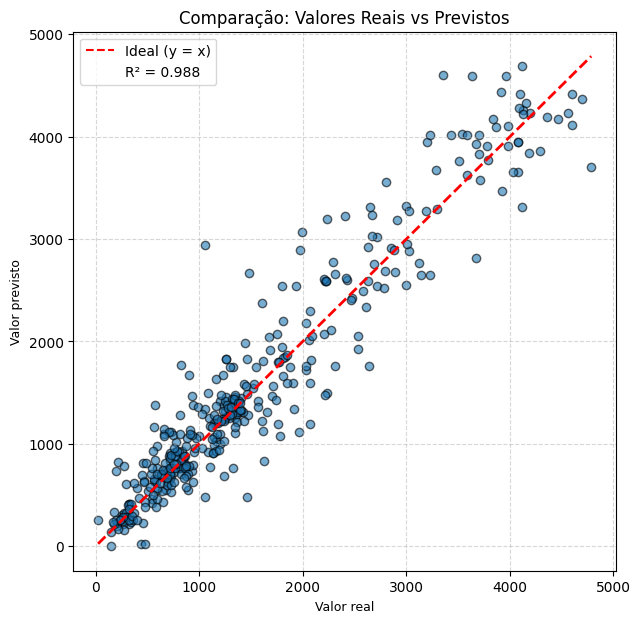

In [11]:
# y_test → valores reais
# y_pred → previsões do modelo

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2,label="Ideal (y = x)")
         #label="Ideal (y = x)")


plt.xlabel("Valor real", fontsize=9)
plt.ylabel("Valor previsto", fontsize=9)
plt.title("Comparação: Valores Reais vs Previstos", fontsize=12)
r2_handle = mlines.Line2D([], [], color='none', label=f"R² = {r2:.3f}")
#plt.legend(handles=[r2_handle])
#plt.legend()
plt.legend(handles=[plt.Line2D([],[], color='r', linestyle='--', label='Ideal (y = x)'), r2_handle])
plt.grid(True, linestyle='--', alpha=0.5)
#plt.text(
    #0.01 * max(y_test),   # posição x (ajuste conforme necessário)
    #0.99 * max(y_pred),   # posição y (ajuste conforme necessário)
    #f'$R^2 = {r2:.3f}$',  # texto formatado
    #fontsize=12,
    #color='black',
    #bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')  # fundo branco
#)
plt.show()

Erro absoluto médio (MAE): 238.48683074265978
R² (coeficiente de determinação): 0.9063099694854371
Raiz do erro quadrático médio (RMSE): 345.8245917023661

Importância das variáveis:
 restaurante_utilizado_RU    0.592566
periodo_semestre_ferias     0.120191
tipo_refeicao_Jantar        0.080605
tipo_refeicao_Almoço        0.049607
categoria_padrao_peixe      0.044276
mes_jul                     0.023995
dia_semana_sex              0.016649
mes_dez                     0.011140
restaurante_utilizado_RS    0.008374
mes_abr                     0.003870
dtype: float64


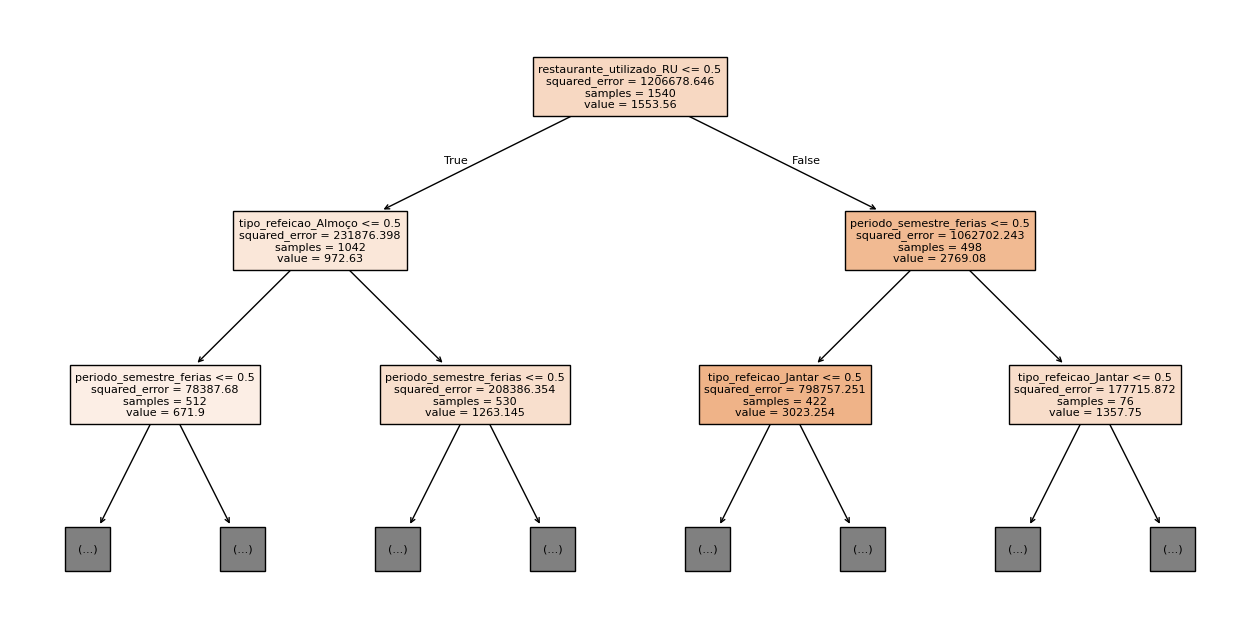

In [12]:
# 8. Avaliar desempenho
print("Erro absoluto médio (MAE):", mean_absolute_error(y_test, y_pred))
print("R² (coeficiente de determinação):", r2_score(y_test, y_pred))
print("Raiz do erro quadrático médio (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))

# 9. Importância das variáveis
importances = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nImportância das variáveis:\n", importances.head(10))

 #10. Visualizar árvore
plt.figure(figsize=(16,8))
plot_tree(modelo, feature_names=X.columns, filled=True, fontsize=8, max_depth=2)
plt.show()

In [13]:
desviod = df.groupby("dia_semana")["quantidade"].std()
print(desviod)

dia_semana
qua    1144.907816
qui    1114.698039
seg    1087.107351
sex    1021.575344
ter    1123.219477
Name: quantidade, dtype: float64


FAZENDO AS PREVISÕES DE FATO

In [14]:
#leitura dos dados
nova_semana = pd.read_csv('dados-previsaoParteIIcsv.csv')
nova_semana.head()

,date,tipo_refeicao,restaurante_utilizado,categoria_padrao,categoria_vegano,dia_semana,mes,almoco,periodo_semestre,quantidade,feriado_dummy
0,20/10/2025,Almoço,RU,suino,leguminosas,seg,out,1,meio,NaN,0
1,20/10/2025,Almoço,RA,suino,leguminosas,seg,out,1,meio,NaN,0
2,20/10/2025,Almoço,RS,suino,leguminosas,seg,out,1,meio,NaN,0
3,20/10/2025,Jantar,RU,frango,pts_proteina_texturizada,seg,out,0,meio,NaN,0
4,20/10/2025,Jantar,RA,frango,pts_proteina_texturizada,seg,out,0,meio,NaN,0


In [15]:
print(nova_semana.head())

         date tipo_refeicao restaurante_utilizado categoria_padrao  \
0  20/10/2025        Almoço                    RU            suino   
1  20/10/2025        Almoço                    RA            suino   
2  20/10/2025        Almoço                    RS            suino   
3  20/10/2025        Jantar                    RU           frango   
4  20/10/2025        Jantar                    RA           frango   

           categoria_vegano dia_semana  mes  almoco periodo_semestre  \
0               leguminosas        seg  out       1             meio   
1               leguminosas        seg  out       1             meio   
2               leguminosas        seg  out       1             meio   
3  pts_proteina_texturizada        seg  out       0             meio   
4  pts_proteina_texturizada        seg  out       0             meio   

   quantidade  feriado_dummy  
0         NaN              0  
1         NaN              0  
2         NaN              0  
3         NaN         

In [16]:
nova_semana = nova_semana.drop('date', axis=1) #retirada da coluna date, estava dando erro com ela mas ela não entra como fator na predição então ok
nova_semana_encoded = pd.get_dummies(nova_semana, drop_first= False) #transforma os fatores de cada coluna em dummy igual no treino
nova_semana_encoded.head()

,almoco,quantidade,feriado_dummy,tipo_refeicao_Almoço,tipo_refeicao_Jantar,restaurante_utilizado_RA,restaurante_utilizado_RS,restaurante_utilizado_RU,categoria_padrao_bovino,categoria_padrao_frango,...,categoria_padrao_suino,categoria_vegano_leguminosas,categoria_vegano_pts_proteina_texturizada,dia_semana_qua,dia_semana_qui,dia_semana_seg,dia_semana_sex,dia_semana_ter,mes_out,periodo_semestre_meio
0,1,NaN,0,True,False,False,False,True,False,False,...,True,True,False,False,False,True,False,False,True,True
1,1,NaN,0,True,False,True,False,False,False,False,...,True,True,False,False,False,True,False,False,True,True
2,1,NaN,0,True,False,False,True,False,False,False,...,True,True,False,False,False,True,False,False,True,True
3,0,NaN,0,False,True,False,False,True,False,True,...,False,False,True,False,False,True,False,False,True,True
4,0,NaN,0,False,True,True,False,False,False,True,...,False,False,True,False,False,True,False,False,True,True


In [17]:
nova_semana_encoded.feriado_dummy = 0

In [18]:
# Garantir que as colunas sejam as mesmas do treino
for col in X_train.columns:
    if col not in nova_semana_encoded.columns:
        nova_semana_encoded[col] = 0

In [19]:
# Reordenar colunas para ficar igual ao treino
nova_semana_encoded = nova_semana_encoded[X_train.columns]

In [20]:
print(nova_semana_encoded)

    feriado_dummy  tipo_refeicao_Almoço  tipo_refeicao_Jantar  \
0               0                  True                 False   
1               0                  True                 False   
2               0                  True                 False   
3               0                 False                  True   
4               0                 False                  True   
5               0                 False                  True   
6               0                  True                 False   
7               0                  True                 False   
8               0                  True                 False   
9               0                 False                  True   
10              0                 False                  True   
11              0                 False                  True   
12              0                  True                 False   
13              0                  True                 False   
14              0        

In [21]:
# predição
predicoes = modelo.predict(nova_semana_encoded)
nova_semana['quantidade_prevista'] = predicoes

print(nova_semana[['restaurante_utilizado', 'dia_semana', 'quantidade_prevista', 'almoco']])

   restaurante_utilizado dia_semana  quantidade_prevista  almoco
0                     RU        seg               3190.0       1
1                     RA        seg               1321.0       1
2                     RS        seg               1497.0       1
3                     RU        seg               2883.0       0
4                     RA        seg                897.0       0
5                     RS        seg               1078.0       0
6                     RU        ter               2817.0       1
7                     RA        ter               1165.5       1
8                     RS        ter               1497.0       1
9                     RU        ter               2358.5       0
10                    RA        ter                631.0       0
11                    RS        ter                917.5       0
12                    RU        qua               1763.0       1
13                    RA        qua                672.0       1
14                    RS 

In [22]:
desvio = nova_semana.groupby("dia_semana")["quantidade_prevista"].std()
print(desvio)

dia_semana
qua    784.148307
qui    883.695748
seg    975.930940
sex    939.730050
ter    854.749169
Name: quantidade_prevista, dtype: float64


In [23]:
print(predicoes)

[3190.  1321.  1497.  2883.   897.  1078.  2817.  1165.5 1497.  2358.5
  631.   917.5 1763.   672.   843.  2588.   657.   834.  2908.  1096.
 1750.5 1222.   551.   577.  2917.  1011.  1108.  1637.   440.   382. ]


Negative Binomial Model


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:             quantidade   No. Observations:                 1540
Model:                            GLM   Df Residuals:                     1516
Model Family:        NegativeBinomial   Df Model:                           23
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -12510.
Date:                Sat, 21 Mar 2026   Deviance:                       119.87
Time:                        23:53:03   Pearson chi2:                     111.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3607
Covariance Type:            nonrobust                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

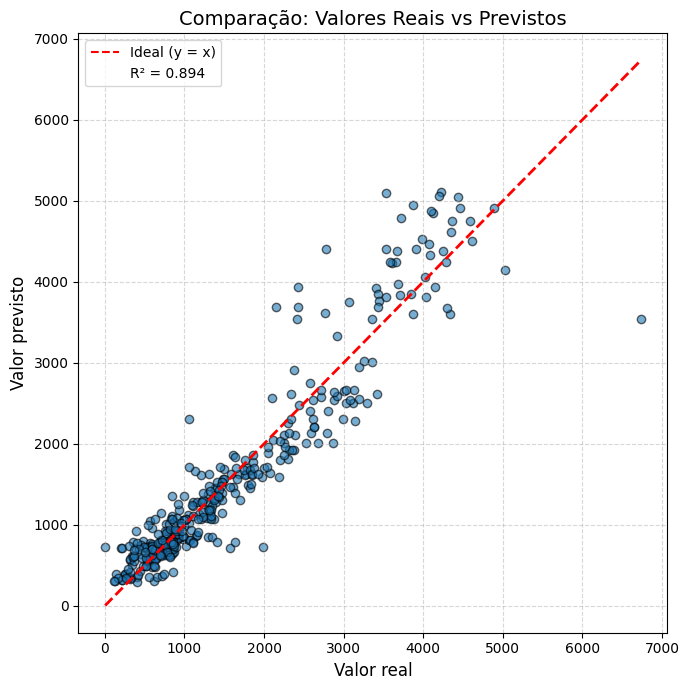

  tipo_refeicao restaurante_utilizado categoria_padrao  \
0        Almoço                    RU            suino   
1        Almoço                    RA            suino   
2        Almoço                    RS            suino   
3        Jantar                    RU           frango   
4        Jantar                    RA           frango   

           categoria_vegano dia_semana  mes  almoco periodo_semestre  \
0               leguminosas        seg  out       1             meio   
1               leguminosas        seg  out       1             meio   
2               leguminosas        seg  out       1             meio   
3  pts_proteina_texturizada        seg  out       0             meio   
4  pts_proteina_texturizada        seg  out       0             meio   

   quantidade  feriado_dummy  quantidade_prevista    previsoes  
0         NaN              0               3190.0  4311.756806  
1         NaN              0               1321.0  1302.295941  
2         NaN          

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

# Reprodutibilidade (equivalente a set.seed(5713) do R)
np.random.seed(5713)
# === 2) Defina X e y e faça o split treino/teste (80/20) ===
# Colunas preditoras — ajuste se necessário (devem existir no seu DataFrame)

dados_completos = df

feature_cols = [
    "almoco",
    "restaurante_utilizado",
    "categoria_padrao",
    "categoria_vegano",
    "dia_semana",
    "periodo_semestre",
    "feriado_dummy"
]

# Variável alvo
target_col = "quantidade"

# Proteção: garantir que as colunas existam
missing = [c for c in feature_cols + [target_col] if c not in dados_completos.columns]
if len(missing) > 0:
    raise ValueError(f"As seguintes colunas estão faltando em dados_completos: {missing}")

X = dados_completos[feature_cols]
y = dados_completos[target_col]

# Split (retorna arrays/frames separados)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5713
)

# Recriar DataFrame para statsmodels usando a mesma estrutura (colunas + target)
dados_treino = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
dados_teste  = pd.concat([X_test.reset_index(drop=True),  y_test.reset_index(drop=True)],  axis=1)

# === 3) Ajustar o modelo Negative Binomial (GLM) ===
# Montamos a fórmula do jeito que você usou no R
formula = "quantidade ~ almoco + restaurante_utilizado + categoria_padrao + " \
          "categoria_vegano + dia_semana + periodo_semestre + feriado_dummy"

modelo_treino = smf.glm(
    formula=formula,
    data=dados_treino,
    family=sm.families.NegativeBinomial()
).fit()

print(modelo_treino.summary())

#R2 treino
prev_treino = modelo_treino.predict(dados_treino)
r2_treino = r2_score(dados_treino["quantidade"], prev_treino)

# === 4) Previsões no conjunto de teste ===
previsoes = modelo_treino.predict(dados_teste)

# Opcional: juntar previsões no dataframe de teste
dados_teste = dados_teste.copy()
dados_teste["previsoes"] = previsoes

# === 5) Gráfico: Valores Reais vs Previstos (estilo matplotlib que você pediu) ===
plt.figure(figsize=(7,7))
plt.scatter(dados_teste["quantidade"], dados_teste["previsoes"], alpha=0.6, edgecolors='k')
plt.plot(
    [dados_teste["quantidade"].min(), dados_teste["quantidade"].max()],
    [dados_teste["quantidade"].min(), dados_teste["quantidade"].max()],
    "r--", lw=2, label="Ideal (y = x)"
)
plt.xlabel("Valor real", fontsize=12)
plt.ylabel("Valor previsto", fontsize=12)
plt.title("Comparação: Valores Reais vs Previstos", fontsize=14)
r2_handle = mlines.Line2D([], [], color='none', label=f"R² = {r2_treino:.3f}")
#plt.legend(handles=[r2_handle])
#plt.legend()
plt.legend(handles=[plt.Line2D([],[], color='r', linestyle='--', label='Ideal (y = x)'), r2_handle])
#plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === 6) Previsões para a nova semana (nova_semana) ===
# Verifique se nova_semana tem as mesmas colunas preditoras; caso contrário, ajuste/transforme.
missing_nova = [c for c in feature_cols if c not in nova_semana.columns]
if len(missing_nova) > 0:
    raise ValueError(f"As seguintes colunas estão faltando em nova_semana: {missing_nova}")

# Gerar previsões e anexar ao DataFrame nova_semana
nova_semana = nova_semana.copy()
nova_semana["previsoes"] = modelo_treino.predict(nova_semana)

# Exibir as primeiras linhas com previsão
print(nova_semana.head())
